In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Исходный диапазон: [25, 245]
Новый диапазон: [0, 50]
Разница: 50


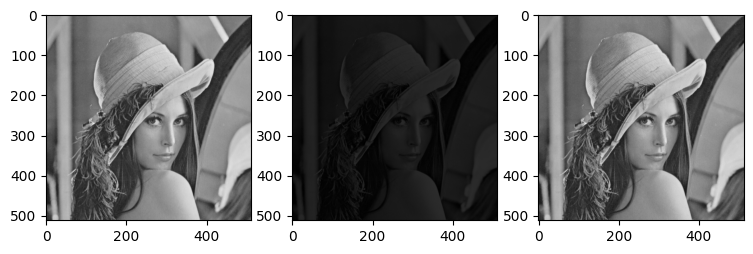

In [46]:

img = cv2.imread('data_img/Lenna.png')

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

base_min = img_gray.min()
base_max = img_gray.max()

new_min = 0
new_max = 50

img_contrasted = np.uint8(
    new_min + (img_gray.astype(np.float32) - base_min) * (new_max - new_min) / (base_max - base_min)
)

print(f"Исходный диапазон: [{base_min}, {base_max}]")
print(f"Новый диапазон: [{img_contrasted.min()}, {img_contrasted.max()}]")
print(f"Разница: {img_contrasted.max() - img_contrasted.min()}")



img_contrasted_back = np.uint8(
    base_min + (img_contrasted.astype(np.float32) - new_min) * (base_max - base_min) / (new_max - new_min)
)

plt.figure(figsize=(9, 3))
plt.subplot(131)
plt.imshow(cv2.cvtColor(img_gray,cv2.COLOR_GRAY2RGB))
plt.subplot(132)
plt.imshow(cv2.cvtColor(img_contrasted, cv2.COLOR_GRAY2RGB))
plt.subplot(133)
plt.imshow(cv2.cvtColor(img_contrasted_back,cv2.COLOR_GRAY2RGB))

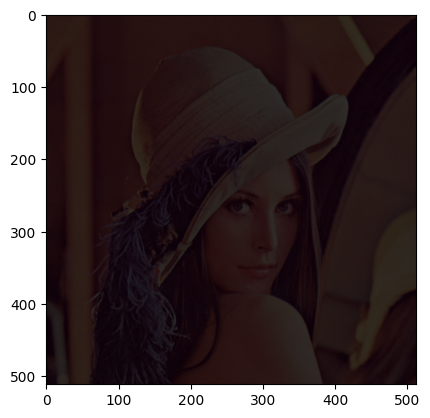

In [40]:
base_min = img.min()
base_max = img.max()

img_contrasted_bgr = np.uint8(
    new_min + (img.astype(np.float32) - base_min) * (new_max - new_min) / (base_max - base_min)
)

plt.imshow(cv2.cvtColor(img_contrasted_bgr, cv2.COLOR_BGR2RGB))
plt.show()

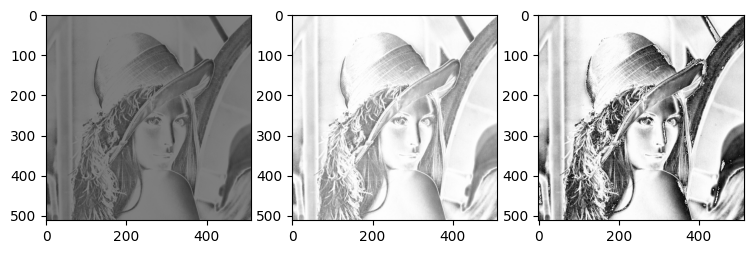

In [36]:
pic = []
numbers = [2,4,8]
for i in numbers:
    k = i / base_max
    img_solarised = np.uint8(
        k * img_gray*(base_max - img_gray)
        )
    pic.append(img_solarised)

plt.figure(figsize=(9, 3))
plt.subplot(131)
plt.imshow(cv2.cvtColor(pic[0],cv2.COLOR_GRAY2RGB))
plt.subplot(132)
plt.imshow(cv2.cvtColor(pic[1], cv2.COLOR_GRAY2RGB))
plt.subplot(133)
plt.imshow(cv2.cvtColor(pic[2],cv2.COLOR_GRAY2RGB))


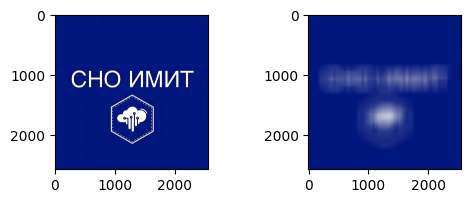

In [11]:
img_text = cv2.imread('data_img/text.jpg')
kernel_identity = np.array([[0,0,0], [0,1,0],[0,0,0]])

kernel = np.ones((255,255),np.float32) / (pow(255,2))
output = cv2.filter2D(img_text, -1, kernel)


plt.figure(figsize=(6, 2))
plt.subplot(121)
plt.imshow(cv2.cvtColor(img_text,cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.show()

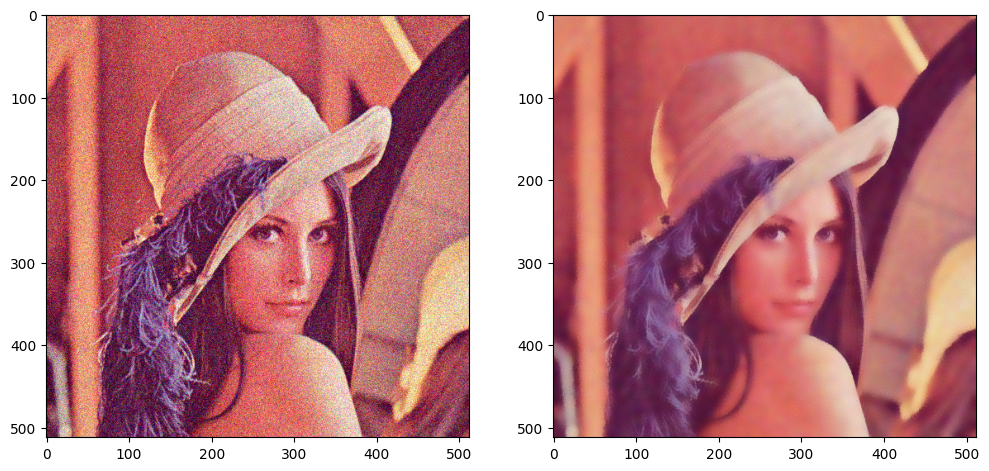

In [53]:
def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255).astype(np.uint8)
    return noisy_image

noisy = add_gaussian_noise(img, mean=0, sigma=30)

blur = cv2.bilateralFilter(noisy, 15, 150, 150)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.imshow(cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB))
plt.subplot(122)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))

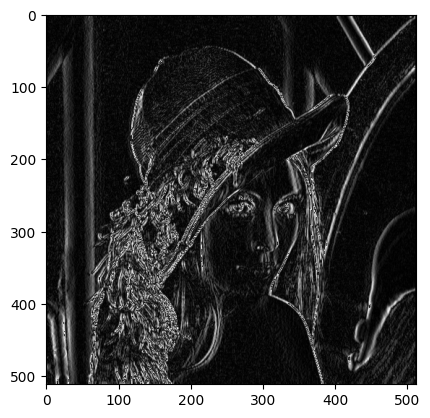

In [49]:
# Собель
GRAY = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sobelx64f = cv2.Sobel(GRAY,cv2.CV_64F,1,0,ksize=3)
abs_sobel64f = np.absolute(sobelx64f)
sobel_horizontal = np.uint8(abs_sobel64f)

sobelx64f_1 = cv2.Sobel(GRAY,cv2.CV_64F,0,1,ksize=3)
abs_sobel64f_1 = np.absolute(sobelx64f_1)
sobel_vertical = np.uint8(abs_sobel64f_1)

plt.imshow(cv2.cvtColor(sobel_horizontal, cv2.COLOR_BGR2RGB))

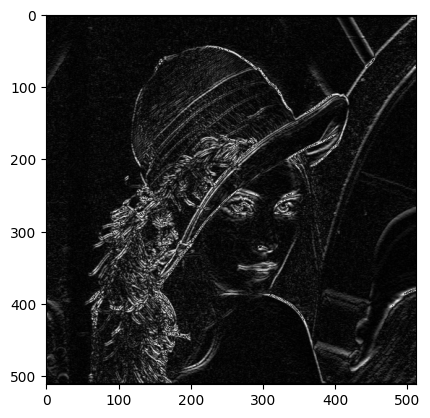

In [ ]:
# Лаплас
laplx64f_1 = cv2.Laplacian(GRAY, cv2.CV_64F)
abs_lapl64f_1 = np.absolute(laplx64f_1)
laplacian = np.uint8(abs_sobel64f_1)

plt.imshow(cv2.cvtColor(laplacian, cv2.COLOR_BGR2RGB))

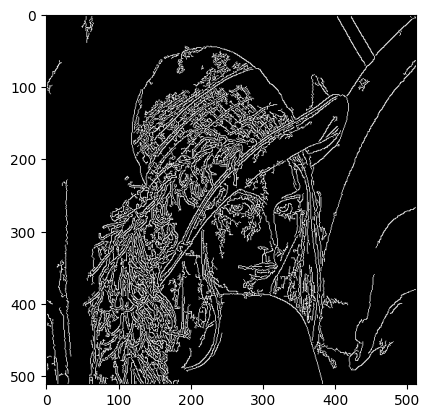

In [ ]:
# Канни
canny = cv2.Canny(GRAY, 20, 150)
plt.imshow(cv2.cvtColor(canny, cv2.COLOR_BGR2RGB))